# PCA and clustering

Inputs: data/clean.parquet (reviewed listings only)

Outputs:
- outputs/evidence_cluster.json (numbers cited in the report)
- outputs/pca_table.csv
- outputs/cluster_profiles.csv
- outputs/fig_pca_clusters.png (report Figure 3)
- outputs/fig_elbow.png
- outputs/fig_dendrogram.png


### Section 0: Setup


In [39]:
import json
import pathlib

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Constants:
PROJECT_ROOT = pathlib.Path().resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data"
DEFAULT_ROUNDING_DECIMALS = 4
RANDOM_SEED = 20008
N_CLUSTERS_RANGE = range(2, 9)
FIGURE_SAMPLE_SIZE = 5000
DENDROGRAM_SAMPLE_SIZE = 2000


# Utility function used to round a value to a given number of places
def round_value(value, digits=DEFAULT_ROUNDING_DECIMALS):
    return round(float(value), digits)


evidence = {}

# Listings dataframe
listings = pd.read_parquet(DATA_DIR / "clean.parquet")


### Section 1: Data


In [40]:
# Clustering covers reviewed listings only. The 4,477 zero-review listings all share the
# artificial fill value 4,594 for days_since_last_review, so they would collapse into a
# fake cluster that describes the imputation rather than the listings.
listings_reviewed = listings[listings["has_review"] == 1].copy()

evidence["n_rows_full"] = len(listings)
evidence["n_hosts_full"] = listings["host_id"].nunique()
evidence["superhost_rate_full"] = round_value(listings["y"].mean())
evidence["n_rows_reviewed"] = len(listings_reviewed)
evidence["n_hosts_reviewed"] = listings_reviewed["host_id"].nunique()
evidence["superhost_rate_reviewed"] = round_value(listings_reviewed["y"].mean())


### Section 2: Feature sets


In [41]:
# Three candidate feature sets. S3 is used: only a set holding both families lets the PCA
# loadings and cluster centres show which family the data's main structure runs along.
FUNDAMENTAL_FEATURES = ["dist_cbd", "accommodates"]
OPERATIONAL_FEATURES = ["availability_365", "amenity_count", "days_since_last_review", "host_listings_count"]
CANDIDATE_FEATURE_SETS = {
    "S1_operational_only": OPERATIONAL_FEATURES,
    "S2_fundamentals_only": FUNDAMENTAL_FEATURES,
    "S3_mixed": FUNDAMENTAL_FEATURES + OPERATIONAL_FEATURES,
}
CLUSTER_FEATURES = CANDIDATE_FEATURE_SETS["S3_mixed"]
LOG_FEATURES = ["days_since_last_review", "host_listings_count", "dist_cbd"]
CLUSTER_GUARDS = FUNDAMENTAL_FEATURES + OPERATIONAL_FEATURES

clustering_input = listings_reviewed[CLUSTER_FEATURES].copy()

# Evidence for the feature-set choice and for the exclusions
evidence["candidate_feature_sets"] = {name: columns for name, columns in CANDIDATE_FEATURE_SETS.items()}
evidence["skew_before_log"] = {column: round_value(clustering_input[column].skew(), 2) for column in CLUSTER_FEATURES}
evidence["max_before_log"] = {column: round_value(clustering_input[column].max(), 2) for column in CLUSTER_FEATURES}
evidence["price_missing_reviewed_pct"] = round_value(listings_reviewed["price_num"].isna().mean() * 100, 2)
evidence["price_skew_reviewed"] = round_value(listings_reviewed["price_num"].skew(), 2)
evidence["price_max_reviewed"] = round_value(listings_reviewed["price_num"].max(), 2)
evidence["minimum_nights_le3_pct"] = round_value((listings_reviewed["minimum_nights"] <= 3).mean() * 100, 2)
evidence["minimum_nights_skew"] = round_value(listings_reviewed["minimum_nights"].skew(), 2)


### Section 3: Preprocessing


In [42]:
# Log transform the three skewed features: PCA and K-Means are driven by variance and
# distance, so a single maximum of 667 listings would dominate the first component.
# log1p rather than log: days_since_last_review reaches 0, and log(0) is negative
# infinity. A single infinite value makes the scaler's mean and standard deviation
# infinite, and every distance after it is meaningless.
log_transformed = clustering_input.copy()
for column in LOG_FEATURES:
    log_transformed[column] = np.log1p(log_transformed[column])

# Standardise all six: without it, availability_365 (0-365) outweighs accommodates (1-16)
# and PC1 becomes nothing but "days available".
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(log_transformed),
    columns=CLUSTER_FEATURES,
    index=log_transformed.index,
)

# Sanity check on the standardisation: every column should be centred and unit-scaled
evidence["scaled_mean_abs_max"] = round_value(scaled_features.mean().abs().max(), 6)
evidence["scaled_std_min"] = round_value(scaled_features.std(ddof=0).min())


### Section 4: PCA


In [43]:
pca = PCA()
principal_components = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

evidence["n_components"] = int(len(explained_variance))
evidence["explained_variance_first3"] = [round_value(value) for value in explained_variance[:3]]
evidence["cumulative_variance_first3"] = [round_value(value) for value in cumulative_variance[:3]]

# For each of the first three components, the three features with the largest loadings
# by absolute value. The signs are kept: a component can be flipped as a whole, so what
# matters is which features share a sign and which oppose.
pca_rows = []
for component_index in range(3):
    loadings = pd.Series(pca.components_[component_index], index=CLUSTER_FEATURES)
    top_loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index)[:3]
    row = {
        "component": f"PC{component_index + 1}",
        "explained_variance": round_value(explained_variance[component_index]),
        "cumulative_variance": round_value(cumulative_variance[component_index]),
    }
    for rank, (feature, value) in enumerate(top_loadings.items(), start=1):
        row[f"loading_{rank}_feature"] = feature
        row[f"loading_{rank}_value"] = round_value(value, 3)
    pca_rows.append(row)
pca_table = pd.DataFrame(pca_rows)

evidence["pca_top_loadings"] = {
    row["component"]: [
        [row[f"loading_{rank}_feature"], row[f"loading_{rank}_value"]] for rank in (1, 2, 3)
    ]
    for row in pca_rows
}

pca_table


,component,explained_variance,cumulative_variance,loading_1_feature,loading_1_value,loading_2_feature,loading_2_value,loading_3_feature,loading_3_value
0,PC1,0.3211,0.3211,days_since_last_review,0.563,amenity_count,-0.504,availability_365,-0.447
1,PC2,0.2045,0.5255,dist_cbd,0.786,host_listings_count,-0.556,accommodates,0.208
2,PC3,0.1681,0.6936,accommodates,0.671,availability_365,-0.591,amenity_count,0.355


### Section 5: K-Means


In [44]:
# Fit K-Means once per candidate k. Same seed and same n_init throughout, so the only
# thing that changes from one row of the table to the next is k itself.
# distortion = inertia = the sum of squared distances from each listing to its own
# cluster centre. It is the quantity K-Means minimises, and it falls for every extra
# cluster, so the curve is read for its bend rather than for its minimum.
distortions = []
for k in N_CLUSTERS_RANGE:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    kmeans.fit(scaled_features)
    distortions.append(kmeans.inertia_)

kmeans_sweep = pd.DataFrame({"k": list(N_CLUSTERS_RANGE), "distortion": distortions})
evidence["kmeans_sweep"] = kmeans_sweep.round(DEFAULT_ROUNDING_DECIMALS).to_dict("records")

# ---- Elbow plot ----
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.plot(kmeans_sweep["k"], kmeans_sweep["distortion"], "bx-")
axis.set(title="The elbow method showing the optimal k", xlabel="k", ylabel="Distortion (inertia)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_elbow.png", dpi=150)
plt.close(figure)

# k is read off the bend in the distortion curve. The bend is located as the point
# furthest from the straight line joining the first and last points, which is the same
# judgement the eye makes on the plot above, written down so it is not made by hand.
# Both axes are scaled to 0-1 first, because k and distortion are in different units.
scaled_k = (kmeans_sweep["k"] - kmeans_sweep["k"].min()) / (kmeans_sweep["k"].max() - kmeans_sweep["k"].min())
scaled_distortion = (kmeans_sweep["distortion"] - kmeans_sweep["distortion"].min()) / (
    kmeans_sweep["distortion"].max() - kmeans_sweep["distortion"].min()
)
distance_from_chord = np.abs(scaled_distortion - (1 - scaled_k))

CHOSEN_K = int(kmeans_sweep["k"].iloc[int(np.argmax(distance_from_chord))])
evidence["chosen_k"] = CHOSEN_K
evidence["chosen_k_distortion"] = round_value(kmeans_sweep.loc[kmeans_sweep["k"] == CHOSEN_K, "distortion"].iloc[0], 1)
evidence["chord_distances"] = {int(k): round_value(d) for k, d in zip(kmeans_sweep["k"], distance_from_chord)}

kmeans_final = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED)
kmeans_labels = kmeans_final.fit_predict(scaled_features)

evidence["kmeans_sizes"] = {int(k): int(v) for k, v in pd.Series(kmeans_labels).value_counts().sort_index().items()}
kmeans_sweep


,k,distortion
0,2,99719.989454
1,3,83737.567319
2,4,72991.522583
3,5,64211.445707
4,6,59864.584345
5,7,56113.169452
6,8,53229.237140


### Section 6: Hierarchical


In [45]:
# Run on all 21,251 rows. sklearn gives the labels directly, so there is no linkage
# matrix and no separate cut step. The spec requires both methods to use the same k,
# which is passed in as n_clusters.
# Ward merges the pair of clusters that adds the least within-cluster variance, which is
# the same quantity K-Means minimises, so a disagreement between the two methods comes
# from partitioning versus hierarchical merging rather than from different objectives.
# Single and average linkage collapse on this data: they return [21,247, 1, 1, 1, 1] and
# [19,482, 1, 341, 1,401, 26], because one chain of nearby listings absorbs the rest.
hierarchical_model = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(scaled_features)

evidence["hierarchical_sizes"] = {int(k): int(v) for k, v in pd.Series(hierarchical_labels).value_counts().sort_index().items()}
evidence["hierarchical_clusters_returned"] = int(pd.Series(hierarchical_labels).nunique())


### Section 7: Comparing the two methods


In [46]:
# Cluster numbering is arbitrary, so the comparison runs through the cross-tabulation
# rather than through the labels themselves. The crosstab and the size columns are the
# evidence: they show which clusters correspond one-to-one and which are split.
cluster_crosstab = pd.crosstab(
    pd.Series(kmeans_labels, name="kmeans_cluster"),
    pd.Series(hierarchical_labels, name="hierarchical_cluster"),
)

evidence["kmeans_vs_hierarchical_sizes"] = {
    "kmeans": evidence["kmeans_sizes"],
    "hierarchical": evidence["hierarchical_sizes"],
}
evidence["crosstab"] = {str(k): {str(k2): int(v) for k2, v in row.items()} for k, row in cluster_crosstab.to_dict().items()}

cluster_crosstab


hierarchical_cluster,0,1,2,3,4
kmeans_cluster,,,,,
0,3506,457,0,1,577
1,2438,764,0,41,2097
2,4101,57,5,1,525
3,105,916,333,511,500
4,2323,259,0,8,1726


### Section 8: Cluster profiles


In [47]:
def build_cluster_profiles(labels, method_name):
    """Median of each clustering feature in original units, plus the superhost rate."""
    frame = listings_reviewed.assign(cluster=labels)
    profiles = frame.groupby("cluster").agg(
        listings=("cluster", "size"),
        superhost_rate=("y", "mean"),
        **{column: (column, "median") for column in CLUSTER_FEATURES},
    )
    profiles.insert(0, "method", method_name)
    profiles.insert(2, "share", profiles["listings"] / len(frame))
    return profiles.round(DEFAULT_ROUNDING_DECIMALS)


cluster_profiles = pd.concat(
    [
        build_cluster_profiles(kmeans_labels, "KMeans"),
        build_cluster_profiles(hierarchical_labels, "Hierarchical"),
    ]
).reset_index(names="cluster")

# y appears for the first time here, and only to describe the clusters
evidence["cluster_profiles"] = cluster_profiles.to_dict("records")
evidence["kmeans_superhost_rate_spread"] = round_value(
    cluster_profiles.query("method == 'KMeans'")["superhost_rate"].max()
    - cluster_profiles.query("method == 'KMeans'")["superhost_rate"].min()
)
evidence["hierarchical_superhost_rate_spread"] = round_value(
    cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].max()
    - cluster_profiles.query("method == 'Hierarchical'")["superhost_rate"].min()
)

cluster_profiles


,cluster,method,listings,share,superhost_rate,dist_cbd,accommodates,availability_365,amenity_count,days_since_last_review,host_listings_count
0,0,KMeans,4541,0.2137,0.3532,1.4173,4.0,188.0,41.0,50.0,50.0
1,1,KMeans,5340,0.2513,0.5395,2.2476,4.0,157.0,47.0,40.0,2.0
2,2,KMeans,4689,0.2206,0.0676,4.5432,2.0,0.0,23.0,1883.0,1.0
3,3,KMeans,2365,0.1113,0.4368,20.5645,8.0,218.0,51.0,58.0,3.0
4,4,KMeans,4316,0.2031,0.4066,17.8220,2.0,310.0,33.0,76.0,2.0
5,0,Hierarchical,12473,0.5869,0.2709,3.1519,2.0,125.0,31.0,112.0,3.0
6,1,Hierarchical,2453,0.1154,0.4501,6.1814,6.0,282.0,51.0,51.0,6.0
7,2,Hierarchical,338,0.0159,0.3669,22.0619,12.0,293.0,56.0,58.5,13.0
8,3,Hierarchical,562,0.0264,0.5391,24.0894,8.0,158.0,59.0,58.0,2.0
9,4,Hierarchical,5425,0.2553,0.4940,7.5801,3.0,133.0,47.0,62.0,2.0


### Section 9: Figures


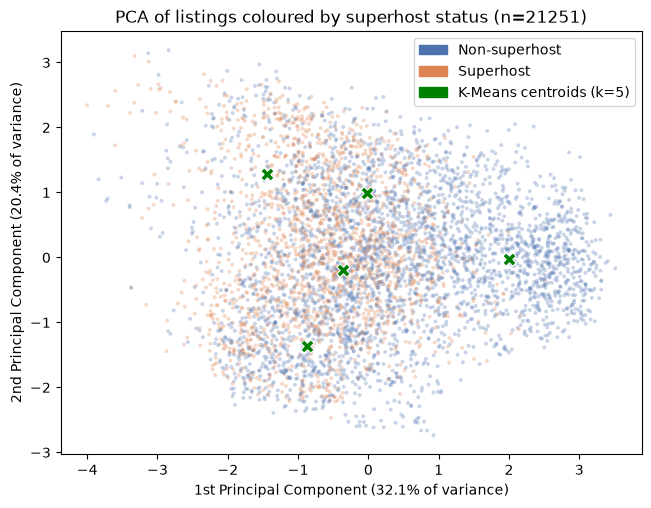

In [48]:
# Dendrogram
dendrogram_sample = scaled_features.sample(DENDROGRAM_SAMPLE_SIZE, random_state=RANDOM_SEED)
figure, axis = plt.subplots(figsize=(9, 4.5))
dendrogram(linkage(dendrogram_sample.to_numpy(), method="ward"), truncate_mode="lastp", p=30, ax=axis, no_labels=True)
axis.set(title=f"Ward dendrogram (n={DENDROGRAM_SAMPLE_SIZE}, k={CHOSEN_K})", ylabel="Merge distance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_dendrogram.png", dpi=150)
plt.close(figure)

# PCA Scatterplot 
STATUS_COLOURS = {"Non-superhost": "#4C72B0", "Superhost": "#DD8452"}
sample_positions = np.random.default_rng(RANDOM_SEED).choice(
    len(principal_components), min(FIGURE_SAMPLE_SIZE, len(principal_components)), replace=False
)
scatter_frame = pd.DataFrame(
    {
        "PC1": principal_components[sample_positions, 0],
        "PC2": principal_components[sample_positions, 1],
        "Status": np.where(listings_reviewed["y"].to_numpy()[sample_positions] == 1, "Superhost", "Non-superhost"),
    }
)
centres_in_pc_space = pca.transform(pd.DataFrame(kmeans_final.cluster_centers_, columns=CLUSTER_FEATURES))

figure, axis = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=scatter_frame, x="PC1", y="PC2", hue="Status", palette=STATUS_COLOURS, s=8, alpha=0.3, linewidth=0, legend=False, ax=axis)
sns.scatterplot(x=centres_in_pc_space[:, 0], y=centres_in_pc_space[:, 1], marker="X", s=90, color="green", ax=axis)
axis.set(
    xlabel=f"1st Principal Component ({explained_variance[0] * 100:.1f}% of variance)",
    ylabel=f"2nd Principal Component ({explained_variance[1] * 100:.1f}% of variance)",
    title=f"PCA of listings coloured by superhost status (n={len(listings_reviewed)})",
)
axis.legend(
    handles=[Patch(color=colour, label=status) for status, colour in STATUS_COLOURS.items()]
    + [Patch(color="green", label=f"K-Means centroids (k={CHOSEN_K})")],
    loc="upper right",
)
plt.savefig(OUTPUT_DIR / "fig_pca_clusters.png", dpi=150)
plt.close(figure)

figure


### Section 10: Save


In [49]:
# Checks before saving
assert len(listings_reviewed) == evidence["n_rows_reviewed"]
assert scaled_features.notna().all().all()
assert evidence["n_components"] == len(CLUSTER_FEATURES)
assert evidence["hierarchical_clusters_returned"] == CHOSEN_K
assert len(dendrogram_sample) == DENDROGRAM_SAMPLE_SIZE

pca_table.to_csv(OUTPUT_DIR / "pca_table.csv", index=False)
cluster_profiles.round(DEFAULT_ROUNDING_DECIMALS).to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)
with open(OUTPUT_DIR / "evidence_cluster.json", "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)

print(f"rows clustered        : {len(scaled_features):,}")
print(f"chosen k              : {CHOSEN_K}")
print(f"PC1 / PC2 variance    : {explained_variance[0] * 100:.1f}% / {explained_variance[1] * 100:.1f}%")


rows clustered        : 21,251
chosen k              : 5
PC1 / PC2 variance    : 32.1% / 20.4%
